## 게임 스탯-데미지 상관관계 및 회귀 분석
본 노트북은 컴퓨터 비전(OCR) 파이프라인을 통해 직접 수집한 인게임 스탯/데미지 데이터를 바탕으로, 데미지 공식을 역추적하고 데미지 편차(난수)를 분석하는 과정을 담고 있습니다.

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler

### 1. 데이터 로드 및 전처리
SQLite DB에서 원본 데이터를 불러와 학습용(Train)과 테스트용(Test) 데이터셋으로 분할

In [4]:
# DB 연결 및 원본 데이터 로드
conn = sqlite3.connect('DataFile.db')
query = "SELECT intelligence, specialty, weapon_atk, total_atk, damage_value FROM damage_logs"
df= pd.read_sql_query(query, conn)
conn.close()

df

,intelligence,specialty,weapon_atk,total_atk,damage_value
0,5324,0,2938,1632,495460
1,5324,0,2938,1632,480018
2,5324,0,2938,1632,471851
3,5324,0,2938,1632,470907
4,5324,0,2938,1632,486817
...,...,...,...,...,...
5007,6407,160,2938,1790,578438
5008,6407,160,2938,1790,605525
5009,6407,160,2938,1790,593027
5010,6407,160,2938,1790,601644


In [5]:
# Test set 분할
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [6]:
X_train = df_train[['intelligence', 'specialty', 'weapon_atk', 'total_atk']]
y_train = df_train['damage_value']

### 2. 다중공선성 진단 및 피처 셀렉션 (Feature Selection)
수집한 4가지 스탯(지능, 특화, 무기 공격력, 총 공격력) 중 데미지 예측에 유의미한 변수를 선별하기 위해 OLS 회귀 분석과 상관관계 및 이를 시각화 한 상관관계 히트맵(Heatmap)을 확인

In [7]:
X_train_ols = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_ols).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           damage_value   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 9.945e+04
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:38:58   Log-Likelihood:                -41800.
No. Observations:                4009   AIC:                         8.361e+04
Df Residuals:                    4004   BIC:                         8.364e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.538e+04    933.234     16.475      0.000    1.35e+04    1.72e+04
intelligence     0.2271      0.485      0.468      0.640      -0.725       1.179
specialty      302.4818      2.118    142.840      0.000     298.330     306.634
weapon_atk       1.0704      1.685      0.635      0.525      -2.233       4.374
total_atk      288.5477      4.464     64.637      0.000     279.796     297.300
==============================================================================
Omnibus:                      298.295   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1193.039
Skew:                          -0.269   Prob(JB):                    8.61e-260
Kurtosis:                       5.618   Cond. No.                     4.84e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.84e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
X_train.corr()

,intelligence,specialty,weapon_atk,total_atk
intelligence,1.000000,-0.031518,-0.185893,0.220870
specialty,-0.031518,1.000000,-0.021263,-0.036847
weapon_atk,-0.185893,-0.021263,1.000000,0.911636
total_atk,0.220870,-0.036847,0.911636,1.000000


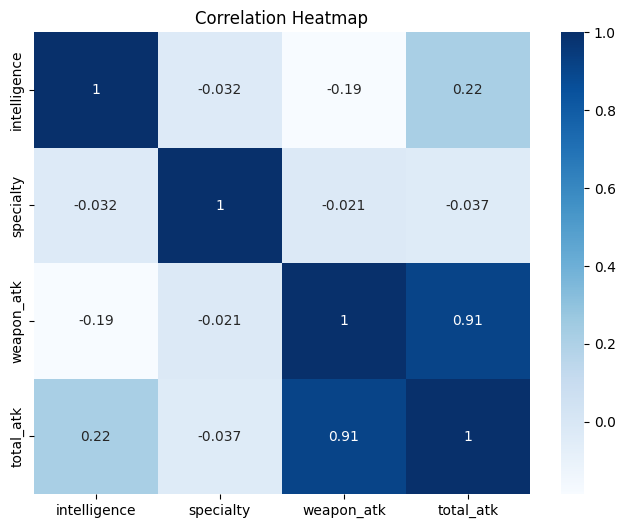

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

### 3. 변수 선별 결과 및 Lasso 회귀 적용
위 OLS Summary의 p-value와 히트맵을 살펴보면, 지능과 무기공격력은 다른 변수에 종속적인 성향이 강해 예측 변수로 부적합할 개연성이 높음   
이를 보다 명확히 검증하기 위해 정규화 기법인 LassoCV를 적용하여 불필요한 스탯의 계수(Coefficient)를 축소 및 최종 제거

In [10]:
# LassoCV를 통한 확실한 predictor 선별
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
lasso = LassoCV(cv=5).fit(X_train_scaled, y_train)

lasso.coef_ 
# 좌측(0)부터 지능 특화 무공 공격력

array([    0.        , 18374.42009936,   221.89248977, 79659.823339  ])

In [11]:
# 불필요한 스탯 제거, 필요한 스탯만 분리
# 지능은 완전히 탈락, 무기공격력은 0으로 죽어버리지는 않았으나 다른 두 preditor들에 비해 값이 월등히 작으므로 error에 의한 것이라고 판단&제거
X_final_train = df_train[['total_atk', 'specialty']].copy()
X_final_test = df_test[['total_atk', 'specialty']].copy()

### 4. Log 변환을 통한 공식 선형화 및 회귀 모델 적합
게임 내 데미지 연산은 일반적으로 '데미지 = (기본 공격력) * (1 + 특화 계수)'와 같은 곱연산 구조    
따라서 이를 다중 선형 회귀에 알맞은 합연산 구조로 전환하기 위해, 독립변수와 종속변수 모두에 Log 변환(np.log)을 적용

In [12]:
# Log 변환 (곱연산 공식 -> 합연산 공식)
X_log_train = pd.DataFrame({'log_total_atk': np.log(X_final_train['total_atk']), 'specialty': X_final_train['specialty']})
y_log_train = np.log(df_train['damage_value'])

X_log_test = pd.DataFrame({'log_total_atk': np.log(X_final_test['total_atk']), 'specialty': X_final_test['specialty']})
y_log_test = np.log(df_test['damage_value'])

# 최종 선형 회귀 모델 학습
model_final = LinearRegression()
model_final.fit(X_log_train, y_log_train)

# [공격력, 특화]
model_final.coef_

array([8.97220014e-01, 7.11589967e-04])

In [13]:
# Test 데이터 평가
r2_score = model_final.score(X_log_test, y_log_test)
r2_score

0.9919977053574037

Log 변환을 거친 회귀 모델이 평균 데미지를 매우 높은 정확도($R^2$)로 예측

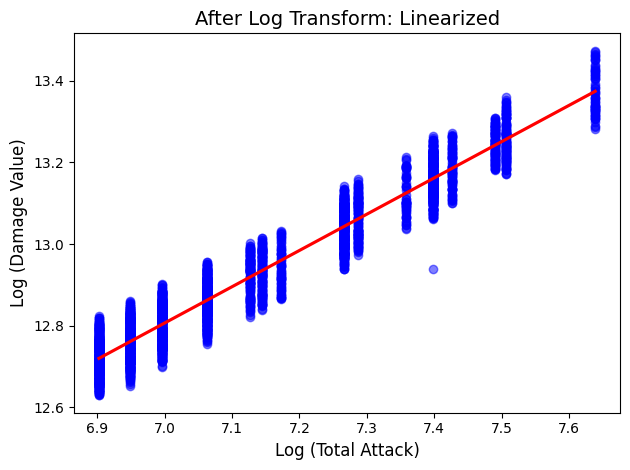

In [14]:
# 산점도 + 선형 회귀 모델 예측선(직선)
sns.regplot(x=X_log_train['log_total_atk'], y=y_log_train, color='blue', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("After Log Transform: Linearized", fontsize=14)
plt.xlabel("Log (Total Attack)", fontsize=12)
plt.ylabel("Log (Damage Value)", fontsize=12)

plt.tight_layout()
plt.show()

## 5. 잔차(Residual) 분석을 통한 데미지 난수 폭 검증

실제 데이터와 예측값의 차이인 잔차(Residual)를 구한 뒤, 로그 스케일을 다시 지수 함수(np.exp)로 역변환하여 인게임 타격 시 발생하는 고유의 데미지 편차(최소~최대 데미지 난수 비율)를 도출

In [15]:
# 원본 데이터(df)에 찾아낸 공식을 씌워 에러(난수)만 추출
X_log = pd.DataFrame({'log_total_atk': np.log(df['total_atk']), 'specialty': df['specialty']})
y_log = np.log(df['damage_value'])

In [16]:
# 예측 수행 및 잔차(편차) 계산
y_pred = model_final.predict(X_log)
residuals = y_log - y_pred

In [17]:
# 모든 잔차를 실제 데미지 비율(%)로 일괄 변환
residuals_percentage = (np.exp(residuals) - 1) * 100

In [18]:
# 최대/최소 범위 추출
max_error_percentage = np.max(residuals_percentage) # 퍼센트 최대값
min_error_percentage = np.min(residuals_percentage) # 퍼센트 최소값

In [19]:
print(f"추정 데미지 난수 범위: {min_error_percentage:.2f}% ~ {max_error_percentage:.2f}%")

추정 데미지 난수 범위: -14.12% ~ 3.99%


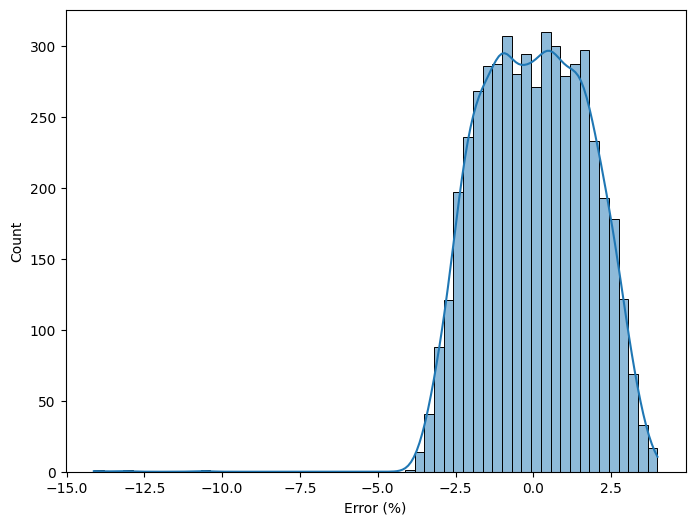

In [20]:
# 분포 시각화
plt.figure(figsize=(8, 6))
sns.histplot(residuals_percentage, kde=True)
plt.xlabel("Error (%)")
plt.show()

### 6. 이상치 제거 및 반복
여러 값과 시각화된 그래프를 통해 outlier의 존재를 확인  
해당 이상치를 제거 후 4, 5번 과정 반복 시행

In [21]:
# Extra. 범위를 이상하게 벗어난 값이 존재함을 알았으니 처음으로 돌아가서 outlier 쳐내기 <- error rate 기준으로 제거

# 앞서 계산한 편차(residuals_percentage)를 원본 데이터에 파생 변수로 추가
df['error_pct'] = residuals_percentage

Q1 = df['error_pct'].quantile(0.25)
Q3 = df['error_pct'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df['error_pct'] < (Q1 - 1.5 * IQR)) | (df['error_pct'] > (Q3 + 1.5 * IQR)))].copy()

In [22]:
# outlier 제거 버전으로 다시 log scale 변환, fitting
df_clean_train, df_clean_test = train_test_split(df_clean, test_size=0.2, random_state=42)

X_log_clean_train = pd.DataFrame({
    'log_total_atk': np.log(df_clean_train['total_atk']), 
    'specialty': df_clean_train['specialty']
})
y_log_clean_train = np.log(df_clean_train['damage_value'])

X_log_clean_test = pd.DataFrame({
    'log_total_atk': np.log(df_clean_test['total_atk']), 
    'specialty': df_clean_test['specialty']
})
y_log_clean_test = np.log(df_clean_test['damage_value'])

model_final_clean = LinearRegression()
model_final_clean.fit(X_log_clean_train, y_log_clean_train)

model_final_clean.coef_

array([8.97833423e-01, 7.13602789e-04])

In [23]:
print(f"공격력 계수: {model_final_clean.coef_[0]:.8f}")
print(f"특화 계수: {model_final_clean.coef_[1]:.8f}")

공격력 계수: 0.89783342
특화 계수: 0.00071360


In [24]:
final_r2_score = model_final_clean.score(X_log_clean_test, y_log_clean_test)
final_r2_score

0.9921451558503895

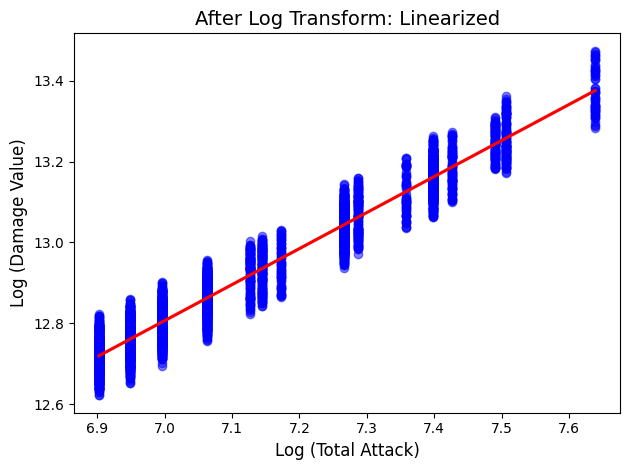

In [25]:
sns.regplot(x=X_log_clean_train['log_total_atk'], y=y_log_clean_train, color='blue', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("After Log Transform: Linearized", fontsize=14)
plt.xlabel("Log (Total Attack)", fontsize=12)
plt.ylabel("Log (Damage Value)", fontsize=12)

plt.tight_layout()
plt.show()

In [26]:
X_log_clean_all = pd.DataFrame({
    'log_total_atk': np.log(df_clean['total_atk']), 
    'specialty': df_clean['specialty']
})
y_log_clean_all = np.log(df_clean['damage_value'])

y_pred_clean = model_final_clean.predict(X_log_clean_all)
residuals_clean = y_log_clean_all - y_pred_clean

final_residuals_percentage = (np.exp(residuals_clean) - 1) * 100

final_max_err = np.max(final_residuals_percentage)
final_min_err = np.min(final_residuals_percentage)

print(f"추정 데미지 난수 범위: {final_min_err:.2f}% ~ {final_max_err:.2f}%")

추정 데미지 난수 범위: -3.89% ~ 4.01%


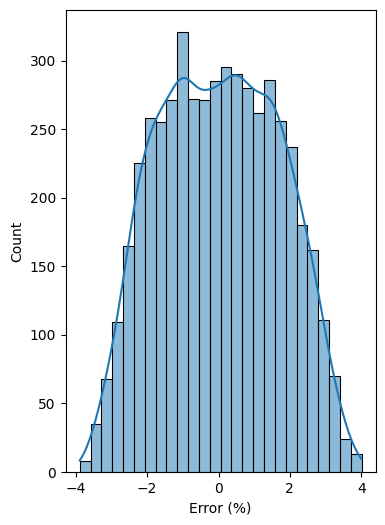

In [27]:
plt.figure(figsize=(4, 6))
sns.histplot(final_residuals_percentage, kde=True)
plt.xlabel("Error (%)")
plt.show()